1. CARREGANDO BANCO DE DADOS

In [30]:
dados <- read.csv(
  "exportacao_cargas.csv.gz",
  header = TRUE,
  sep = ",",
  stringsAsFactors = FALSE
)

dim(dados)
names(dados)
str(dados[, c(
  "TOTAL_TONELADAS",
  "TOTAL_TEU",
  "TOTAL_UNID",
  "ANO",
  "MES"
)])

[1] 1097014      16

[1] "TOTAL_TEU"       "NUMERO_VIAGEM"   "TIPO_NAVEGACAO"  "MOVIMENTO"      
 [5] "ANO"             "TERMINAIS"       "TOTAL_TONELADAS" "NATUREZA_CARGA" 
 [9] "TOTAL_UNID"      "MES"             "CLASSENAVIO"     "SENTIDO"        
[13] "TIPO_INSTALACAO" "BERCOS"          "MERCADORIAS"     "ANO_MES"

'data.frame':	1097014 obs. of  5 variables:
 $ TOTAL_TONELADAS: chr  "1504,855" "190,55" "5631,35" "596,37" ...
 $ TOTAL_TEU      : int  92 28 598 30 317 14 12 2 53 15 ...
 $ TOTAL_UNID     : int  76 14 335 24 227 14 12 1 53 10 ...
 $ ANO            : int  2012 2012 2012 2012 2012 2012 2012 2012 2012 2012 ...
 $ MES            : int  11 10 10 11 11 11 11 11 10 10 ...


2. PREPARANDO AS VARIÁVEIS

In [31]:
# Selecionar cargas conteinerizadas
dados_reg <- subset(
  dados,
  NATUREZA_CARGA == "CARGA CONTEINERIZADA"
)

# Conferir como as variáveis foram importadas
str(dados_reg[, c(
  "TOTAL_TONELADAS",
  "TOTAL_TEU",
  "TOTAL_UNID",
  "ANO",
  "MES"
)])

# Converter as variáveis numéricas
dados_reg$TOTAL_TONELADAS <- as.numeric(
  gsub(",", ".", dados_reg$TOTAL_TONELADAS)
)

dados_reg$TOTAL_TEU <- as.numeric(
  gsub(",", ".", dados_reg$TOTAL_TEU)
)

dados_reg$TOTAL_UNID <- as.numeric(
  gsub(",", ".", dados_reg$TOTAL_UNID)
)

dados_reg$ANO <- as.numeric(
  as.character(dados_reg$ANO)
)

dados_reg$MES <- as.numeric(
  as.character(dados_reg$MES)
)

# Manter registros válidos
variaveis <- c(
  "TOTAL_TONELADAS",
  "TOTAL_TEU",
  "TOTAL_UNID",
  "ANO",
  "MES"
)

dados_reg <- dados_reg[
  complete.cases(dados_reg[, variaveis]) &
    is.finite(dados_reg$TOTAL_TONELADAS) &
    is.finite(dados_reg$TOTAL_TEU) &
    is.finite(dados_reg$TOTAL_UNID) &
    dados_reg$TOTAL_TONELADAS >= 0 &
    dados_reg$TOTAL_TEU >= 0 &
    dados_reg$TOTAL_UNID >= 0,
  variaveis
]

dim(dados_reg)
summary(dados_reg)

'data.frame':	978320 obs. of  5 variables:
 $ TOTAL_TONELADAS: chr  "1504,855" "190,55" "5631,35" "596,37" ...
 $ TOTAL_TEU      : int  92 28 598 30 317 14 12 2 53 15 ...
 $ TOTAL_UNID     : int  76 14 335 24 227 14 12 1 53 10 ...
 $ ANO            : int  2012 2012 2012 2012 2012 2012 2012 2012 2012 2012 ...
 $ MES            : int  11 10 10 11 11 11 11 11 10 10 ...


[1] 978320      5

 TOTAL_TONELADAS       TOTAL_TEU         TOTAL_UNID           ANO      
 Min.   :    1.158   Min.   :   1.00   Min.   :   1.00   Min.   :2005  
 1st Qu.:   37.400   1st Qu.:   3.00   1st Qu.:   2.00   1st Qu.:2010  
 Median :  145.250   Median :  11.00   Median :   8.00   Median :2016  
 Mean   :  892.874   Mean   :  82.67   Mean   :  51.54   Mean   :2016  
 3rd Qu.:  585.211   3rd Qu.:  51.00   3rd Qu.:  34.00   3rd Qu.:2021  
 Max.   :58706.000   Max.   :5445.00   Max.   :3222.00   Max.   :2026  
      MES        
 Min.   : 1.000  
 1st Qu.: 4.000  
 Median : 7.000  
 Mean   : 6.534  
 3rd Qu.:10.000  
 Max.   :12.000  

3. VALIDAÇÃO E VERIFICAÇÃO

In [32]:
# VALIDAÇÃO: Conferir a conversão
cat("Verificando conversão...\n")
cat("TOTAL_TONELADAS - classe:", class(dados_reg$TOTAL_TONELADAS), "\n")
cat("TOTAL_TONELADAS - primeiros valores:\n")
print(head(dados_reg$TOTAL_TONELADAS, 10))
cat("\n")

cat("✓ Registros após conversão CORRIGIDA:", nrow(dados_reg), "\n")
cat("✓ Deve ser ≈ 978.320 (ou próximo)\n\n")

Verificando conversão...
TOTAL_TONELADAS - classe: numeric 
TOTAL_TONELADAS - primeiros valores:
 [1] 1504.855  190.550 5631.350  596.370 4601.841  276.870  187.058   30.250
 [9] 1211.061   30.028

✓ Registros após conversão CORRIGIDA: 978320 
✓ Deve ser ≈ 978.320 (ou próximo)



4. SEPARANDO TREINO E TESTE (70/30)

In [33]:
set.seed(1)

id_treino <- sample(
  seq_len(nrow(dados_reg)),
  size = floor(0.7 * nrow(dados_reg))
)

treino <- dados_reg[id_treino, ]
teste <- dados_reg[-id_treino, ]

nrow(treino)
nrow(teste)

[1] 684824

[1] 293496

5. COMPARANDO MODELOS COM DIFERENTES VARIÁVEIS

In [34]:
# Modelo 1: apenas TOTAL_TEU
m1 <- lm(
  log1p(TOTAL_TONELADAS) ~ log1p(TOTAL_TEU),
  data = treino
)

# Modelo 2: TEU e unidades movimentadas
m2 <- lm(
  log1p(TOTAL_TONELADAS) ~
    log1p(TOTAL_TEU) +
    log1p(TOTAL_UNID),
  data = treino
)

# Modelo 3: acrescentar ano e mês
m3 <- lm(
  log1p(TOTAL_TONELADAS) ~
    log1p(TOTAL_TEU) +
    log1p(TOTAL_UNID) +
    ANO +
    factor(MES),
  data = treino
)

summary(m1)
summary(m2)
summary(m3)


Call:
lm(formula = log1p(TOTAL_TONELADAS) ~ log1p(TOTAL_TEU), data = treino)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.2521 -0.2058  0.2337  0.4813  2.8089 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)      2.338563   0.001752    1335   <2e-16 ***
log1p(TOTAL_TEU) 0.984954   0.000532    1851   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7424 on 684822 degrees of freedom
Multiple R-squared:  0.8335,	Adjusted R-squared:  0.8335 
F-statistic: 3.427e+06 on 1 and 684822 DF,  p-value: < 2.2e-16



Call:
lm(formula = log1p(TOTAL_TONELADAS) ~ log1p(TOTAL_TEU) + log1p(TOTAL_UNID), 
    data = treino)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4108 -0.1421  0.2656  0.4883  2.9834 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       2.455548   0.001753 1400.68   <2e-16 ***
log1p(TOTAL_TEU)  0.163148   0.003484   46.82   <2e-16 ***
log1p(TOTAL_UNID) 0.881917   0.003699  238.44   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7134 on 684821 degrees of freedom
Multiple R-squared:  0.8462,	Adjusted R-squared:  0.8462 
F-statistic: 1.884e+06 on 2 and 684821 DF,  p-value: < 2.2e-16



Call:
lm(formula = log1p(TOTAL_TONELADAS) ~ log1p(TOTAL_TEU) + log1p(TOTAL_UNID) + 
    ANO + factor(MES), data = treino)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4880 -0.1407  0.2672  0.4798  2.9879 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -1.819e+01  2.759e-01 -65.946  < 2e-16 ***
log1p(TOTAL_TEU)   1.387e-01  3.486e-03  39.781  < 2e-16 ***
log1p(TOTAL_UNID)  9.052e-01  3.697e-03 244.854  < 2e-16 ***
ANO                1.025e-02  1.369e-04  74.845  < 2e-16 ***
factor(MES)2      -3.138e-03  4.326e-03  -0.725 0.468289    
factor(MES)3      -4.373e-03  4.219e-03  -1.036 0.299970    
factor(MES)4      -3.875e-03  4.240e-03  -0.914 0.360739    
factor(MES)5       1.507e-03  4.184e-03   0.360 0.718813    
factor(MES)6       5.978e-03  4.210e-03   1.420 0.155589    
factor(MES)7       3.307e-03  4.238e-03   0.780 0.435160    
factor(MES)8       1.395e-03  4.215e-03   0.331 0.740675    
factor(MES)9       1.046e-02  4.223e

6. COMPARANDO ERRO DE PREVISÃO NO TESTE

In [35]:
# Fazer previsões
p1 <- predict(m1, newdata = teste)
p2 <- predict(m2, newdata = teste)
p3 <- predict(m3, newdata = teste)

# Converter previsões de volta para toneladas
p1_ton <- pmax(0, expm1(p1))
p2_ton <- pmax(0, expm1(p2))
p3_ton <- pmax(0, expm1(p3))

# Calcular RMSE na escala original
rmse <- function(real, previsto) {
  sqrt(mean((real - previsto)^2))
}

resultados <- data.frame(
  Modelo = c("TEU", "TEU + Unidades", "TEU + Unidades + Tempo"),
  RMSE = c(
    rmse(teste$TOTAL_TONELADAS, p1_ton),
    rmse(teste$TOTAL_TONELADAS, p2_ton),
    rmse(teste$TOTAL_TONELADAS, p3_ton)
  )
)

resultados

Modelo,RMSE
<chr>,<dbl>
TEU,1201.643
TEU + Unidades,1183.662
TEU + Unidades + Tempo,1188.740


7. INVESTIGANDO QUAIS VARIÁVEIS SÃO IMPORTANTES

In [36]:
# Coeficientes do modelo completo
summary(m3)$coefficients

# Comparar R² ajustado
c(
  M1 = summary(m1)$adj.r.squared,
  M2 = summary(m2)$adj.r.squared,
  M3 = summary(m3)$adj.r.squared
)

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-18.193805775,0.2758892757,-65.9460421,0.000000000
log1p(TOTAL_TEU),0.138659207,0.0034855932,39.7806627,0.000000000
log1p(TOTAL_UNID),0.905184576,0.0036968352,244.8539175,0.000000000
ANO,0.010247397,0.0001369154,74.8447218,0.000000000
factor(MES)2,-0.003137683,0.0043262492,-0.7252663,0.468288933
factor(MES)3,-0.004373187,0.0042191905,-1.0364990,0.299969752
factor(MES)4,-0.003875106,0.0042399121,-0.9139590,0.360738693
factor(MES)5,0.001506619,0.0041845186,0.3600458,0.718812958
factor(MES)6,0.005978266,0.0042098508,1.4200660,0.155588918
factor(MES)7,0.003307106,0.0042377488,0.7803922,0.435160303


M1        M2        M3 
0.8334606 0.8462264 0.8474776

8. VERIFICANDO OS COEFICIENTES DO MODELO

In [37]:
# Coeficientes, significância e ajuste do modelo
summary(m3)


Call:
lm(formula = log1p(TOTAL_TONELADAS) ~ log1p(TOTAL_TEU) + log1p(TOTAL_UNID) + 
    ANO + factor(MES), data = treino)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4880 -0.1407  0.2672  0.4798  2.9879 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -1.819e+01  2.759e-01 -65.946  < 2e-16 ***
log1p(TOTAL_TEU)   1.387e-01  3.486e-03  39.781  < 2e-16 ***
log1p(TOTAL_UNID)  9.052e-01  3.697e-03 244.854  < 2e-16 ***
ANO                1.025e-02  1.369e-04  74.845  < 2e-16 ***
factor(MES)2      -3.138e-03  4.326e-03  -0.725 0.468289    
factor(MES)3      -4.373e-03  4.219e-03  -1.036 0.299970    
factor(MES)4      -3.875e-03  4.240e-03  -0.914 0.360739    
factor(MES)5       1.507e-03  4.184e-03   0.360 0.718813    
factor(MES)6       5.978e-03  4.210e-03   1.420 0.155589    
factor(MES)7       3.307e-03  4.238e-03   0.780 0.435160    
factor(MES)8       1.395e-03  4.215e-03   0.331 0.740675    
factor(MES)9       1.046e-02  4.223e

9. COMPARANDO A CONTRIBUIÇÃO DE CADA VARIÁVEL

In [38]:
# Modelo completo
m_completo <- lm(
  log1p(TOTAL_TONELADAS) ~
    log1p(TOTAL_TEU) +
    log1p(TOTAL_UNID) +
    ANO +
    factor(MES),
  data = treino
)

# Modelos sem uma variável ou grupo de variáveis
m_sem_teu <- lm(
  log1p(TOTAL_TONELADAS) ~
    log1p(TOTAL_UNID) +
    ANO +
    factor(MES),
  data = treino
)

m_sem_unid <- lm(
  log1p(TOTAL_TONELADAS) ~
    log1p(TOTAL_TEU) +
    ANO +
    factor(MES),
  data = treino
)

m_sem_tempo <- lm(
  log1p(TOTAL_TONELADAS) ~
    log1p(TOTAL_TEU) +
    log1p(TOTAL_UNID),
  data = treino
)

# Função para calcular o RMSE na escala original
calcular_rmse <- function(modelo, dados_teste) {
  previsao_log <- predict(modelo, newdata = dados_teste)
  previsao <- pmax(0, expm1(previsao_log))

  sqrt(mean(
    (dados_teste$TOTAL_TONELADAS - previsao)^2
  ))
}

# Comparar os resultados
comparacao <- data.frame(
  Modelo = c(
    "Completo",
    "Sem TOTAL_TEU",
    "Sem TOTAL_UNID",
    "Sem ANO e MES"
  ),
  RMSE = c(
    calcular_rmse(m_completo, teste),
    calcular_rmse(m_sem_teu, teste),
    calcular_rmse(m_sem_unid, teste),
    calcular_rmse(m_sem_tempo, teste)
  )
)

comparacao

Modelo,RMSE
<chr>,<dbl>
Completo,1188.740
Sem TOTAL_TEU,1195.366
Sem TOTAL_UNID,1203.402
Sem ANO e MES,1183.662


10. CRIANDO UM GRÁFICO DOS ERROS

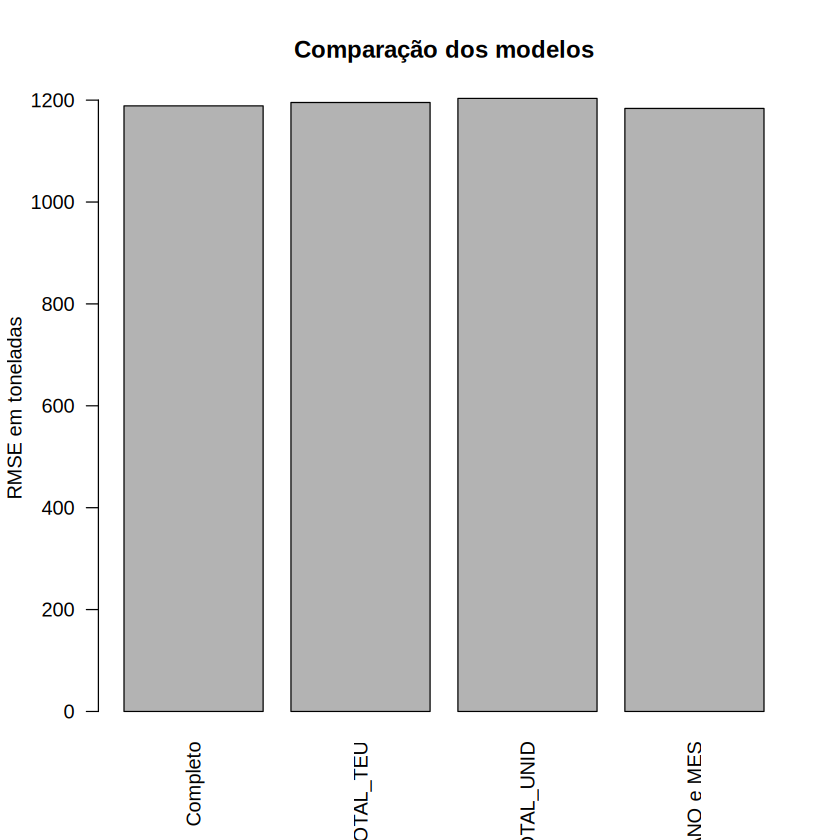

In [39]:
barplot(
  comparacao$RMSE,
  names.arg = comparacao$Modelo,
  las = 2,
  col = "gray70",
  ylab = "RMSE em toneladas",
  main = "Comparação dos modelos"
)

11. VARIFICANDO OS RESÍDUOS DO MODELO COMPLETO

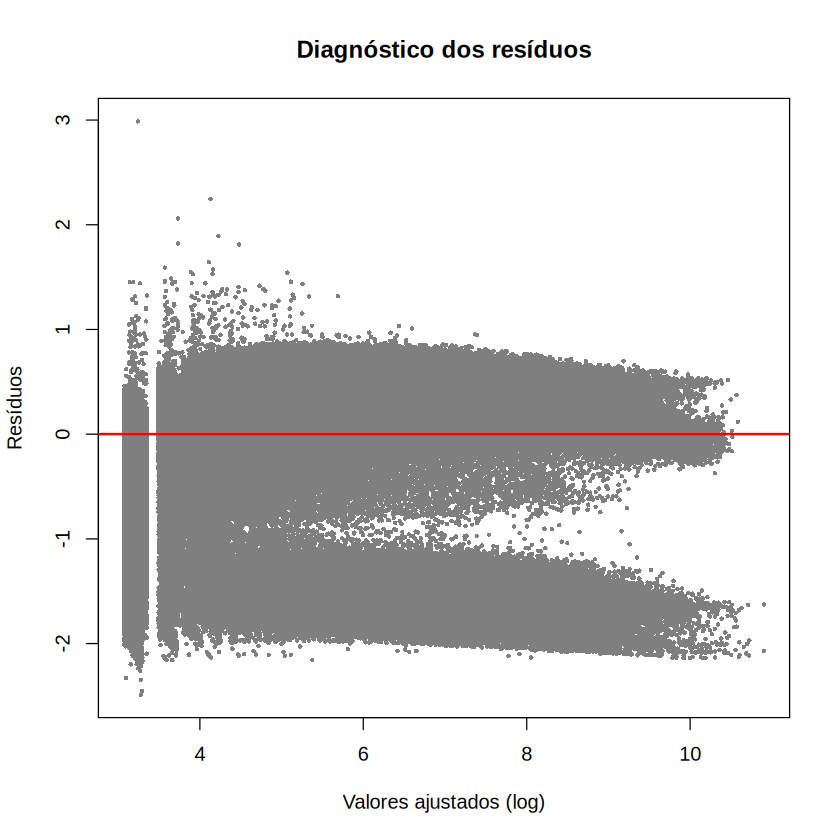

In [40]:
# Previsões e resíduos na escala logarítmica
ajustados <- fitted(m_completo)
residuos <- residuals(m_completo)

# Resíduos versus valores ajustados
plot(
  ajustados,
  residuos,
  pch = 16,
  cex = 0.5,
  col = "gray50",
  xlab = "Valores ajustados (log)",
  ylab = "Resíduos",
  main = "Diagnóstico dos resíduos"
)

abline(h = 0, col = "red", lwd = 2)

12. SALVANDO UMA TABELA COM OS RESULTADOS

In [41]:
write.csv(
  comparacao,
  "comparacao_modelos.csv",
  row.names = FALSE
)

**Resultados da Análise**


Foram comparados modelos de regressão para prever a quantidade de toneladas movimentadas em operações de cargas conteinerizadas no Porto de Santos. A variável resposta foi **TOTAL_TONELADAS**, enquanto as variáveis explicativas avaliadas foram TOTAL_TEU, **TOTAL_UNID, ANO e MES**.


A comparação foi realizada por meio do erro quadrático médio da raiz **(RMSE)**, calculado no conjunto de teste **(293.496 observações)**. Três modelos foram testados com complexidade crescente:


**Modelo 1:** incluindo apenas **TOTAL_TEU** como preditor, com **RMSE** de **1.201,64 toneladas** e **R²** ajustado de **0,8335**

**Modelo 2:** incluindo **TOTAL_TEU e TOTAL_UNID**, com **RMSE** de **1.183,66 toneladas** e **R²** ajustado de **0,8462**

**Modelo 3:** incluindo **TOTAL_TEU, TOTAL_UNID, ANO e MES**, com **RMSE** de **1.188,74 toneladas** e **R²** ajustado de **0,8475**

O modelo com menor **RMSE** foi o **Modelo 2** (que incluiu TOTAL_TEU e TOTAL_UNID como variáveis explicativas), apresentando erro de **1.183,66 toneladas**. Esse modelo oferece o melhor equilíbrio entre precisão preditiva e simplicidade, reduzindo o erro em relação ao **Modelo 1** em **17,98 toneladas (~1,5%)** com a adição de apenas uma variável explicativa.


A análise de retirada de variáveis (análise ablativa) indicou que tanto **TOTAL_UNID** quanto **TOTAL_TEU** contribuíram para o desempenho preditivo na configuração avaliada. Quando **TOTAL_UNID** foi removido do modelo completo, o **RMSE** aumentou de **1.188,74** para **1.203,40 toneladas (aumento de 14,66 toneladas)**. Quando **TOTAL_TEU** foi removido, o **RMSE** aumentou para **1.195,37 toneladas (aumento de 6,63 toneladas)**. A remoção de **ANO** e **MES** resultou em diminuição do **RMSE** para **1.183,66 toneladas**, sugerindo que essas variáveis temporais não agregam valor preditivo significativo para este conjunto de dados específico de carga conteinerizada.


Esses resultados são específicos dos dados e dos modelos testados e não devem ser interpretados como evidência de causalidade. As variáveis **TOTAL_TEU e TOTAL_UNID** mostram maior associação com o volume de toneladas movimentadas em operações conteinerizadas, sendo recomendadas para modelos preditivos futuros.


Conclui-se que a comparação de modelos permite identificar quais variáveis oferecem maior contribuição preditiva para a estimativa da quantidade de toneladas movimentadas. A seleção final do **Modelo 2 (TOTAL_TEU + TOTAL_UNID)** deve considerar tanto o erro em dados não utilizados no treinamento quanto a estabilidade dos resultados, que se mostraram satisfatórios com **R²** ajustado de **0,8462** e **RMSE** de **1.183,66** toneladas em validação.
